# QooQit demo 11/12/2025

### Outline
1. Embedders
2. Creating a QuantumProgram
3. Compiling to a device
4. Executing a QuantumProgram

## 1. Embedders

An embedder is anything that help us to map an abstract problem into something that can be implemented in Pasqal's hardware

In [17]:
import numpy as np

Q = np.array([
        [-10.0, 19.7365809, 19.7365809, 5.42015853, 5.42015853],
        [19.7365809, -10.0, 20.67626392, 0.17675796, 0.85604541],
        [19.7365809, 20.67626392, -10.0, 0.85604541, 0.17675796],
        [5.42015853, 0.17675796, 0.85604541, -10.0, 0.32306662],
        [5.42015853, 0.85604541, 0.17675796, 0.32306662, -10.0],
])
Q = Q/Q.max()

InteractionEmbedder:
| Algorithm: interaction_embedding
| Config: InteractionEmbeddingConfig(method='Nelder-Mead', maxiter=200000, tol=1e-08)


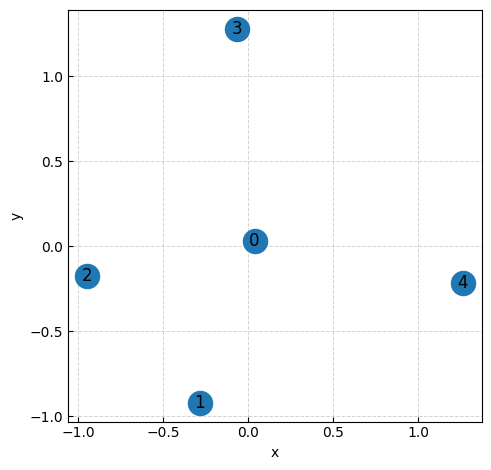

In [18]:
from qoolqit import InteractionEmbedder

embedder = InteractionEmbedder()
print(embedder)

embedded_graph = embedder.embed(Q)
embedded_graph.draw()

# 2. Creating a QuantumProgram

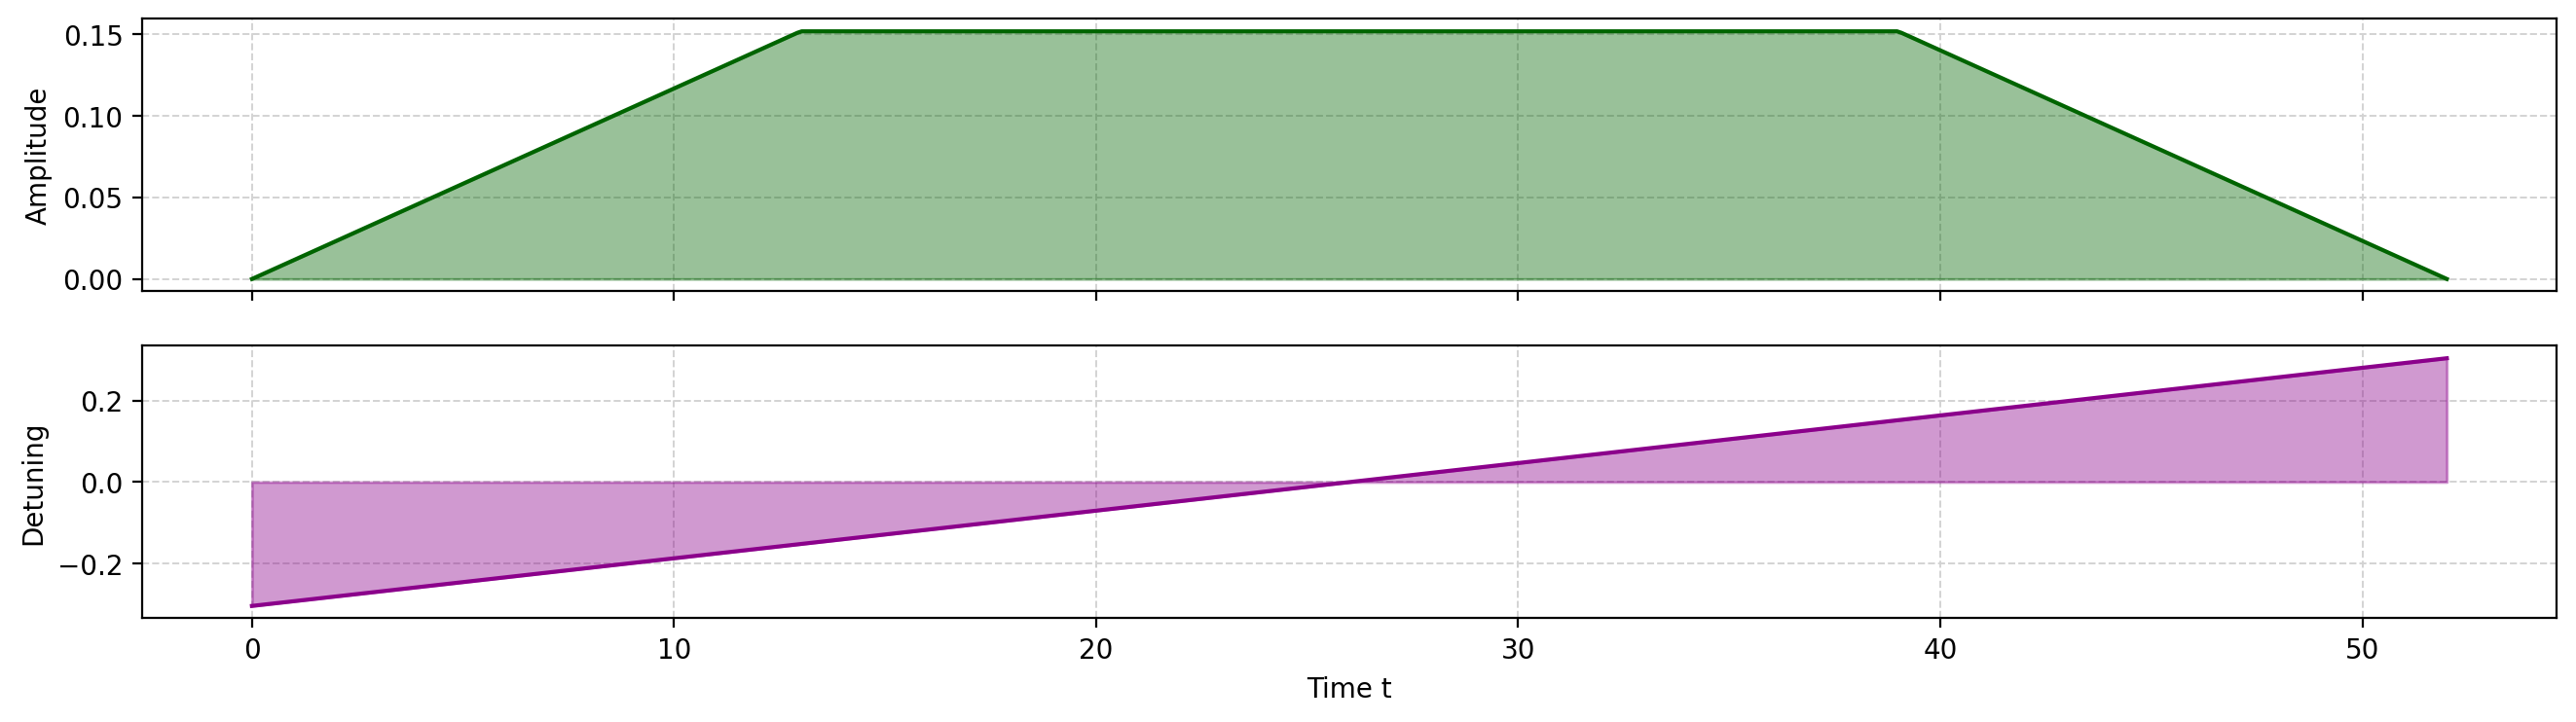

In [19]:
from qoolqit import Drive, PiecewiseLinear, QuantumProgram, Ramp, Register

# Create the register
register = Register.from_graph(embedded_graph)

# Defining the annealing parameters
omega = np.median(Q[Q > 0].flatten())
delta_i = -2.0 * omega
delta_f = 2.0 * omega
T = 52.0

# Defining the annealing schedule
wf_amp = PiecewiseLinear([T/4, T/2, T/4], [0.0, omega, omega, 0.0])
wf_det = Ramp(T, delta_i, delta_f)
drive = Drive(amplitude = wf_amp, detuning = wf_det)

# Writing the quantum program
program = QuantumProgram(register, drive)
program.draw()

# 3. Compiling to a device

In [22]:
from qoolqit import AnalogDevice, CompilerProfile

program.compile_to(device = AnalogDevice(), profile=CompilerProfile.MIN_DISTANCE)